# Part 1: Exploratory Data Analysis (EDA)
This notebook explores the preprocessed product features, visualizes their distributions before and after transformations, and saves plots for the final report.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
os.makedirs('report/figures', exist_ok=True)
os.makedirs('output', exist_ok=True)

## 1. Load Data
We load the preprocessed product features dataset.

In [2]:
df = pd.read_csv('dataset/product_features_clean.csv')
print('Cleaned features shape:', df.shape)
print(df.describe())

Cleaned features shape: (4109, 12)
        total_sold  jumlah_penjualan   avg_rating  total_revenue  \
count  4109.000000       4109.000000  4109.000000    4109.000000   
mean     15.553419         14.141884     4.094520    1665.249404   
std      26.685451         23.448904     0.594517    3415.102586   
min       5.000000          5.000000     1.000000      39.920000   
25%       6.000000          6.000000     3.800000     349.930000   
50%       9.000000          8.000000     4.188679     729.000000   
75%      15.000000         13.000000     4.500000    1626.630000   
max     520.000000        456.000000     5.000000   63885.000000   

       stok_level_orig  jumlah_penjualan_orig  jumlah_penjualan_log  \
count      4109.000000            4109.000000           4109.000000   
mean         97.950792               2.027025             15.127061   
std           5.181641               5.199313             15.015178   
min           0.000000               0.000000              0.000000 

## 2. Compare Sales and Stock Level Skewness
We plot the distribution of stock level using the original linear scaling, log-transform, and rank-based scaling to visualize how the transformations compress skewness.

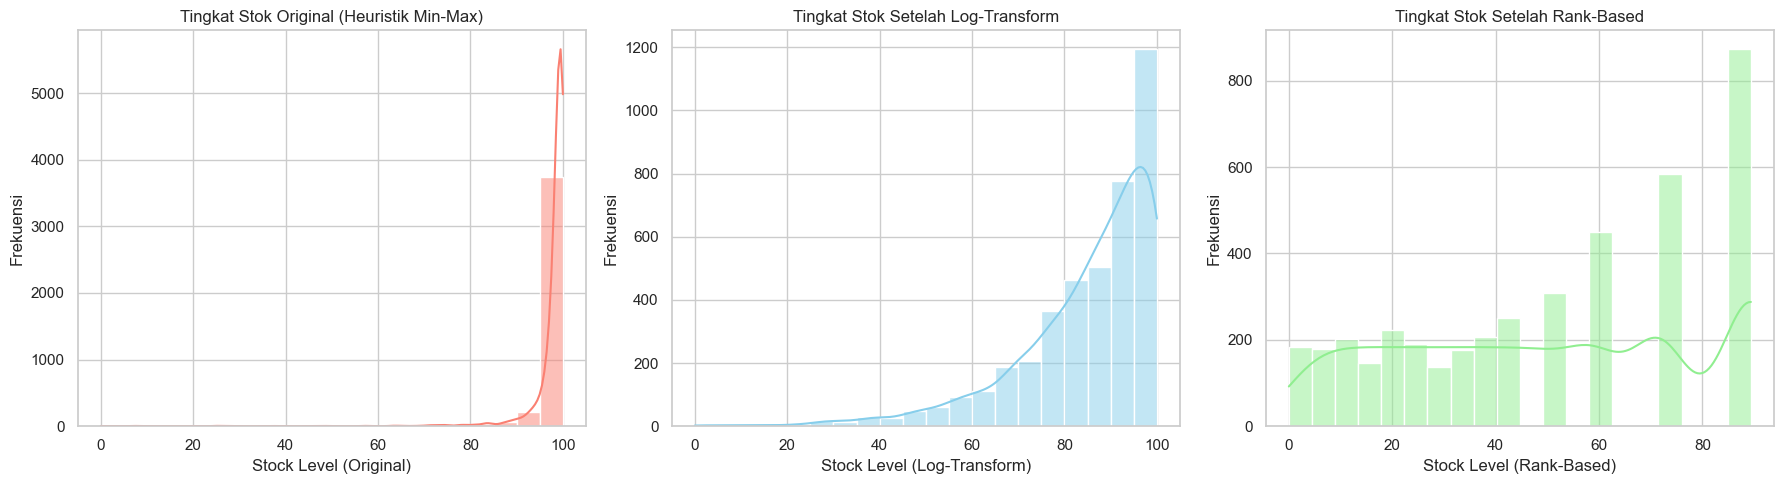

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['stok_level_orig'], bins=20, kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Tingkat Stok Original (Heuristik Min-Max)')
axes[0].set_xlabel('Stock Level (Original)')
axes[0].set_ylabel('Frekuensi')

sns.histplot(df['stok_level_log'], bins=20, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Tingkat Stok Setelah Log-Transform')
axes[1].set_xlabel('Stock Level (Log-Transform)')
axes[1].set_ylabel('Frekuensi')

sns.histplot(df['stok_level_rank'], bins=20, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Tingkat Stok Setelah Rank-Based')
axes[2].set_xlabel('Stock Level (Rank-Based)')
axes[2].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('report/figures/univariate_stok_comparison.png', dpi=150)
plt.savefig('output/univariate_stok_comparison.png', dpi=150)
plt.show()

## 3. Average Rating Distribution
We look at the distribution of product ratings to understand how customers rate products.

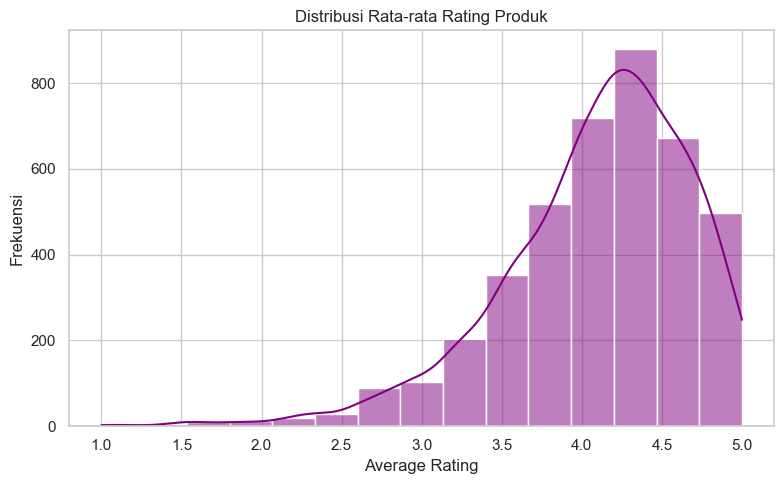

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df['avg_rating'], bins=15, kde=True, color='purple')
plt.title('Distribusi Rata-rata Rating Produk')
plt.xlabel('Average Rating')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.savefig('report/figures/univariate_avg_rating.png', dpi=150)
plt.show()